Stage 1 Model

Take 4km monthly raster data containing weather, terrain, and burned area information, composites it into annual data, and then aggregates it into coarse 1-degree geographical grids. It outputs parquet files, tif files and shapefiles

input files are at gs://clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction

These files are all predictors and the fractional burned values at 4km for fire cci

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from tqdm import tqdm

import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Transformer

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------
# UPDATE: Pointing to the new FWI directory
OUT_DIR = "/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction"

PARQUET_DIR    = Path(OUT_DIR) / "parquet_coarse_grids_annual_new_fwi"
# NOTE: Saves tabular .parquet files. This is your main ML training dataset containing 
# the aggregated predictors (weather/terrain) and the final binary 'burned_label' for each cell.

COARSE_TIF_DIR = Path(OUT_DIR) / "tifs_coarse_grids_annual_new_fwi"
# NOTE: Saves 1-degree .tif raster maps showing ONLY the binary burned/unburned classification. 
# Useful for quickly viewing the 5% threshold results in GIS software.

COARSE_SHP_DIR = Path(OUT_DIR) / "shp_coarse_grids_annual_new_fwi"
# NOTE: Saves 1-degree vector polygon grids (.shp). Contains the cell ID and 'burned_label'. 
# Great for overlaying your classification grid on top of other maps in QGIS/ArcGIS.

os.makedirs(PARQUET_DIR, exist_ok=True)
os.makedirs(COARSE_TIF_DIR, exist_ok=True)
os.makedirs(COARSE_SHP_DIR, exist_ok=True)


# ----------------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------------
WANTED = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code", "fire_weather_index",
    "initial_fire_spread_index",
]

GRID_SIZES_DEG      = [1]
BURNED_THRESHOLD    = 0.05
FRACTION_BAND_NAME  = "fraction"
WRITE_QA_LABEL_ON_4KM = False

# ----------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------
def _norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]", "", s.lower())

WANTED_NORM   = [_norm(x) for x in WANTED]
FRACTION_NORM = _norm(FRACTION_BAND_NAME)

# FIXED: Updated regex to properly match the '_new_fwi_' string in the filename
name_re = re.compile(r"cems_e5l_firecci_(\d{4})_(\d{1,2})_new_fwi_with_fraction\.tif$", re.IGNORECASE)

def parse_year_month(path: Path):
    m = name_re.search(path.name)
    return (int(m.group(1)), int(m.group(2))) if m else None

def map_band_indices_by_name(ds: rio.DatasetReader):
    mapping = {}
    descs = ds.descriptions
    for i, d in enumerate(descs, start=1):
        if d is None: d = f"B{i}"
        mapping[_norm(d)] = i
    return mapping, descs

def compute_lonlat_grid(ds: rio.DatasetReader):
    h, w = ds.height, ds.width
    rows, cols = np.indices((h, w))
    xs, ys = rio.transform.xy(ds.transform, rows, cols, offset="center")
    x, y = np.asarray(xs, dtype=np.float64), np.asarray(ys, dtype=np.float64)
    if ds.crs is None: raise RuntimeError("Dataset has no CRS")
    if ds.crs.to_epsg() == 4326: return x.astype(np.float32), y.astype(np.float32)
    transformer = Transformer.from_crs(ds.crs, "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(x, y)
    return lon.astype(np.float32), lat.astype(np.float32)

def mode_ignore_nan(x: pd.Series):
    x = x.dropna()
    return x.value_counts().idxmax() if not x.empty else np.nan

def aggregate_to_coarse_grids_annual(
    year: int, ds: rio.DatasetReader, predictors_stack: np.ndarray,
    predictor_names: list, annual_frac: np.ndarray, lon: np.ndarray, lat: np.ndarray,
    grid_sizes_deg, burned_threshold, parquet_dir, coarse_tif_dir, coarse_shp_dir, base_name
):
    H, W = ds.height, ds.width
    N = H * W
    lon_flat, lat_flat, frac_flat = lon.ravel(), lat.ravel(), annual_frac.ravel()

    binary_4km_flat = np.zeros_like(frac_flat, dtype=np.uint8)
    valid_frac = ~np.isnan(frac_flat)
    binary_4km_flat[valid_frac & (frac_flat > 0)] = 1 

    pred_flat = {name: band.ravel() for name, band in zip(predictor_names, predictors_stack)}
    valid_idx = np.nonzero(valid_frac)[0]
    if valid_idx.size == 0: return

    frac_valid, bin_valid = frac_flat[valid_frac], binary_4km_flat[valid_frac]
    lon_valid, lat_valid = lon_flat[valid_frac], lat_flat[valid_frac]
    pred_valid = {name: arr[valid_frac] for name, arr in pred_flat.items()}

    for size_deg in grid_sizes_deg:
        # Check if parquet exists before aggregating
        parquet_path = parquet_dir / f"{base_name}_grid{size_deg}deg.parquet"
        if parquet_path.exists():
            print(f"[SKIP] Parquet exists: {parquet_path}")
            continue

        big_lon = size_deg * np.floor(lon_valid / size_deg)
        big_lat = size_deg * np.floor(lat_valid / size_deg)

        df_dict = {
            "big_lon": big_lon.astype(np.float32), "big_lat": big_lat.astype(np.float32),
            "burned_4km": bin_valid, "frac_4km": frac_valid, "flat_idx": valid_idx,
        }
        for name in predictor_names: df_dict[name] = pred_valid[name].astype(np.float32)

        df = pd.DataFrame(df_dict)
        agg_dict = {"burned_4km": "mean", "frac_4km": "mean"}
        for name in predictor_names:
            if name == "b1": agg_dict[name] = mode_ignore_nan
            elif name in ["relative_humidity", "total_precipitation_sum"]: agg_dict[name] = "min"
            elif name in ["temperature_2m", "temperature_2m_min", "temperature_2m_max", 
                        "build_up_index", "drought_code", "duff_moisture_code", 
                        "fine_fuel_moisture_code", "fire_weather_index", "initial_fire_spread_index"]:
                agg_dict[name] = "max"
            else: agg_dict[name] = "mean"

        grouped = df.groupby(["big_lon", "big_lat"], as_index=False).agg(agg_dict)
        grouped = grouped.rename(columns={"burned_4km": "burned_frac_4km"})
        grouped["burned_label"] = (grouped["burned_frac_4km"] >= burned_threshold).astype(np.uint8)
        grouped = grouped.sort_values(["big_lat", "big_lon"]).reset_index(drop=True)
        grouped["ID"] = np.arange(len(grouped), dtype=np.int64)
        grouped["year"], grouped["grid_deg"] = year, size_deg

        grouped.to_parquet(parquet_path, index=False)
        print(f"[PARQUET] Saved {parquet_path}")

        # --- GeoTIFF Output ---
        tif_path = coarse_tif_dir / f"{base_name}_grid{size_deg}deg_epsg4326_burned_unburned.tif"
        if not tif_path.exists():
            min_lon, max_lon = grouped["big_lon"].min(), grouped["big_lon"].max() + size_deg
            min_lat, max_lat = grouped["big_lat"].min(), grouped["big_lat"].max() + size_deg
            transform = from_origin(min_lon, max_lat, size_deg, size_deg)
            width, height = int(np.ceil((max_lon - min_lon) / size_deg)), int(np.ceil((max_lat - min_lat) / size_deg))

            shapes = [(Polygon([(l, t), (l+size_deg, t), (l+size_deg, t+size_deg), (l, t+size_deg)]), int(v)) 
                      for l, t, v in zip(grouped["big_lon"], grouped["big_lat"], grouped["burned_label"])]
            
            coarse_raster = rasterize(shapes=shapes, out_shape=(height, width), transform=transform, fill=255, dtype="uint8")
            profile = {"driver": "GTiff", "height": height, "width": width, "count": 1, "dtype": "uint8",
                       "crs": "EPSG:4326", "transform": transform, "nodata": 255, "compress": "LZW"}
            with rio.open(tif_path, "w", **profile) as dst: dst.write(coarse_raster, 1)
            print(f"[TIF] Saved {tif_path}")

        # --- Shapefile Output ---
        shp_path = coarse_shp_dir / f"{base_name}_grid{size_deg}deg_cells_epsg4326.shp"
        if not shp_path.exists():
            geoms = [Polygon([(l, t), (l+size_deg, t), (l+size_deg, t+size_deg), (l, t+size_deg)]) 
                     for l, t in zip(grouped["big_lon"], grouped["big_lat"])]
            shp_gdf = gpd.GeoDataFrame({"ID": grouped["ID"], "burned_label": grouped["burned_label"]}, 
                                        geometry=geoms, crs="EPSG:4326")
            shp_gdf.to_file(shp_path)
            print(f"[SHP] Saved {shp_path}")

# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
# FIXED: Updated glob pattern to catch _new_fwi_ files
monthly_tifs = sorted(Path(OUT_DIR).glob("cems_e5l_firecci_*_new_fwi_with_fraction.tif"))
year_to_paths = defaultdict(list)
for p in monthly_tifs:
    ym = parse_year_month(p)
    if ym: year_to_paths[ym[0]].append((ym[1], p))

for year in sorted(year_to_paths.keys()):
    # FIXED: Updated the expected parquet name to match the new output pattern
    expected_parquet = PARQUET_DIR / f"cems_e5l_firecci_{year}_annual_new_fwi_grid1deg.parquet"
    if expected_parquet.exists():
        print(f"[SKIP YEAR] All outputs for {year} appear to exist.")
        continue

    month_paths = sorted(year_to_paths[year], key=lambda x: x[0])
    print(f"\n[YEAR] {year} — Processing {len(month_paths)} files")

    with rio.open(month_paths[0][1]) as ds_template:
        H, W = ds_template.height, ds_template.width
        band_map, _ = map_band_indices_by_name(ds_template)
        
        predictor_indices, predictor_names = [], []
        for want_norm, want_orig in zip(WANTED_NORM, WANTED):
            if want_norm in band_map:
                predictor_indices.append(band_map[want_norm]); predictor_names.append(want_orig)
            else:
                for k_norm, idx in band_map.items():
                    if want_norm in k_norm or k_norm in want_norm:
                        predictor_indices.append(idx); predictor_names.append(want_orig); break
        
        frac_idx = band_map.get(FRACTION_NORM)
        if frac_idx is None: continue

        frac_months = []
        pred_months = {name: [] for name in predictor_names}

        for _, path in month_paths:
            with rio.open(path) as ds_m:
                for name, idx in zip(predictor_names, predictor_indices):
                    pred_months[name].append(ds_m.read(idx).astype(np.float32))
                frac_months.append(ds_m.read(frac_idx).astype(np.float32))

        annual_frac = np.nanmax(np.stack(frac_months), axis=0)
        predictor_arrays = [np.nanmean(np.stack(pred_months[n]), axis=0).astype(np.float32) for n in predictor_names]
        lon, lat = compute_lonlat_grid(ds_template)

        # FIXED: Updated base_name to include _new_fwi
        aggregate_to_coarse_grids_annual(
            year, ds_template, np.stack(predictor_arrays), predictor_names, annual_frac, lon, lat,
            GRID_SIZES_DEG, BURNED_THRESHOLD, PARQUET_DIR, COARSE_TIF_DIR, COARSE_SHP_DIR, f"cems_e5l_firecci_{year}_annual_new_fwi"
        )

print("\n[DONE]")


[YEAR] 2001 — Processing 12 files


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:228: RuntimeWarning: All-NaN slice encountered
  annual_frac = np.nanmax(np.stack(frac_months), axis=0)
/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:229: RuntimeWarning: Mean of empty slice
  predictor_arrays = [np.nanmean(np.stack(pred_months[n]), axis=0).astype(np.float32) for n in predictor_names]


[PARQUET] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/parquet_coarse_grids_annual_new_fwi/cems_e5l_firecci_2001_annual_new_fwi_grid1deg.parquet
[TIF] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/tifs_coarse_grids_annual_new_fwi/cems_e5l_firecci_2001_annual_new_fwi_grid1deg_epsg4326_burned_unburned.tif


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:180: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_gdf.to_file(shp_path)
/home/spotter5/.conda/envs/xgboost_gpu/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'burned_label' to 'burned_lab'
  ogr_write(


[SHP] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/shp_coarse_grids_annual_new_fwi/cems_e5l_firecci_2001_annual_new_fwi_grid1deg_cells_epsg4326.shp

[YEAR] 2002 — Processing 12 files


...

[SHP] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/shp_coarse_grids_annual_new_fwi/cems_e5l_firecci_2021_annual_new_fwi_grid1deg_cells_epsg4326.shp

[YEAR] 2022 — Processing 12 files


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:228: RuntimeWarning: All-NaN slice encountered
  annual_frac = np.nanmax(np.stack(frac_months), axis=0)
/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:229: RuntimeWarning: Mean of empty slice
  predictor_arrays = [np.nanmean(np.stack(pred_months[n]), axis=0).astype(np.float32) for n in predictor_names]


[PARQUET] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/parquet_coarse_grids_annual_new_fwi/cems_e5l_firecci_2022_annual_new_fwi_grid1deg.parquet
[TIF] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/tifs_coarse_grids_annual_new_fwi/cems_e5l_firecci_2022_annual_new_fwi_grid1deg_epsg4326_burned_unburned.tif


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4049166/1786858326.py:180: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_gdf.to_file(shp_path)


[SHP] Saved /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/shp_coarse_grids_annual_new_fwi/cems_e5l_firecci_2022_annual_new_fwi_grid1deg_cells_epsg4326.shp

[DONE]


Train stage 1 Model

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Stage-1 LightGBM model (FASTER + FIXED for LightGBM 4.x):
Predict burned_label on 1-degree coarse-grid cells (EPSG:4326)

- Reads all *_grid1deg.parquet from 'new_fwi' folder across all years
- Uses selected predictor columns only
- Stratified K-Fold CV
- Randomized hyperparameter tuning (manual ParameterSampler)
- Optimizes for recall
- Uses early stopping via callbacks (LightGBM 4.x compatible)
- Finds optimal probability threshold (0.10–0.90) from OOF probabilities
- Saves model + metrics + plots to 'new_fwi' output folder
"""

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import joblib

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix


# ---------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------
# UPDATED: Pointing to the new 'new_fwi' directory containing the 0.05 threshold files
PARQUET_DIR = Path(
    "/explore/nobackup/people/spotter5/clelland_fire_ml/"
    "training_e5l_cems_firecci_new_fwi_with_fraction/parquet_coarse_grids_annual_new_fwi"
)

# UPDATED: Output directory also has _new_fwi suffix
OUT_DIR = Path(
    "/explore/nobackup/people/spotter5/clelland_fire_ml/"
    "training_e5l_cems_firecci_new_fwi_with_fraction/stage_1_model_new_fwi"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
N_SPLITS = 5
RANDOM_STATE = 42

# How many random configs to try (reduce if needed)
N_ITER_SEARCH = 30

# IMPORTANT: avoid nested parallelism
# We'll run CV sequentially and let LightGBM use threads.
LGBM_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", "0")) or os.cpu_count() or 8

# Early stopping rounds (LightGBM callbacks)
EARLY_STOPPING_ROUNDS = 200

THRESHOLDS = np.arange(0.10, 0.91, 0.10)

# Tuning subset control:
# - keep ALL positives
# - sample negatives up to this cap for tuning
NEG_CAP_FOR_TUNING = 300_000

FEATURES = [
    "DEM",
    "slope",
    "aspect",
    "b1",
    "relative_humidity",
    "total_precipitation_sum",
    "temperature_2m",
    "temperature_2m_min",
    "temperature_2m_max",
    "build_up_index",
    "drought_code",
    "duff_moisture_code",
    "fine_fuel_moisture_code",
    "fire_weather_index",
    "initial_fire_spread_index",
]
TARGET = "burned_label"


# ---------------------------------------------------------------------
# METRICS
# ---------------------------------------------------------------------
def iou_from_confusion(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else 0.0


def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(np.uint8)
    return {
        "threshold": float(thr),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "iou": iou_from_confusion(y_true, y_pred),
    }


# ---------------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------------
def load_all_grid1deg(parquet_dir: Path) -> pd.DataFrame:
    files = sorted(parquet_dir.glob("*_grid1deg.parquet"))
    print(f"Looking in: {parquet_dir}")
    print(f"Found {len(files)} 1-degree parquet files")
    if not files:
        raise RuntimeError("No *_grid1deg.parquet files found")

    # Read only needed columns
    cols = FEATURES + [TARGET]
    dfs = [pd.read_parquet(f, columns=cols) for f in files]
    return pd.concat(dfs, ignore_index=True)


def prepare_xy(df: pd.DataFrame):
    df = df[FEATURES + [TARGET]].dropna(axis=0).copy()

    # categorical handling for b1
    df["b1"] = df["b1"].astype("Int64").astype("category")

    X = df[FEATURES]
    y = df[TARGET].astype(np.uint8).to_numpy()

    print("\nDataset size:", len(df))
    print("Class counts:", pd.Series(y).value_counts().to_dict())
    return X, y


def make_tuning_subset(X, y, neg_cap=NEG_CAP_FOR_TUNING, seed=RANDOM_STATE):
    """Keep all positives; cap negatives for tuning to speed up search."""
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    if len(neg_idx) > neg_cap:
        neg_idx = rng.choice(neg_idx, size=neg_cap, replace=False)

    idx = np.concatenate([pos_idx, neg_idx])
    rng.shuffle(idx)

    Xs = X.iloc[idx].copy()
    ys = y[idx].copy()

    print(
        f"\n[TUNING SUBSET] positives={len(pos_idx):,}, "
        f"negatives_used={len(neg_idx):,}, total={len(idx):,}"
    )
    return Xs, ys


# ---------------------------------------------------------------------
# CV TRAIN/EVAL WITH EARLY STOPPING (LightGBM 4.x callbacks)
# ---------------------------------------------------------------------
def cv_oof_prob_with_params(X, y, params, cv, early_stopping_rounds=EARLY_STOPPING_ROUNDS):
    """
    Train one param set across folds with early stopping and return:
      - mean recall across folds at default 0.5 threshold (used for ranking)
      - OOF probabilities
    """
    oof_prob = np.zeros(len(y), dtype=np.float32)
    fold_recalls = []

    for fold, (tr, va) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr], y[tr]
        X_va, y_va = X.iloc[va], y[va]

        model = LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="binary_logloss",
            categorical_feature=["b1"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False)
            ],
        )

        prob = model.predict_proba(X_va)[:, 1].astype(np.float32)
        oof_prob[va] = prob

        pred_05 = (prob >= 0.5).astype(np.uint8)
        fold_recalls.append(recall_score(y_va, pred_05, zero_division=0))

        best_iter = getattr(model, "best_iteration_", None)
        print(f"  Fold {fold}: best_iter={best_iter} recall@0.5={fold_recalls[-1]:.4f}")

    return float(np.mean(fold_recalls)), oof_prob


# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------
def main():
    df = load_all_grid1deg(PARQUET_DIR)
    X, y = prepare_xy(df)

    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    pos_weight = n_neg / max(n_pos, 1)

    print(f"Class imbalance neg/pos = {pos_weight:.1f}")
    print(f"Using LightGBM threads = {LGBM_THREADS}")
    print(f"LightGBM version = {lgb.__version__}")

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # --- tune on subset for speed ---
    X_tune, y_tune = make_tuning_subset(X, y)

    # Base params (use many estimators + early stopping)
    base_params = dict(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=LGBM_THREADS,
        verbosity=-1,
        n_estimators=10_000,  # early stopping decides the true number of trees
    )

    # Smaller, effective search space
    param_dist = {
        "learning_rate": [0.01, 0.02, 0.03, 0.05],
        "num_leaves": [31, 63, 127, 255],
        "max_depth": [-1, 5, 7, 9],
        "min_child_samples": [10, 20, 40, 80],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.0, 0.1, 1.0, 5.0],
        "scale_pos_weight": [pos_weight * f for f in [0.5, 1, 2, 4]],
    }

    sampler = list(ParameterSampler(param_dist, n_iter=N_ITER_SEARCH, random_state=RANDOM_STATE))

    print("\n[TUNING] Starting manual random search with early stopping")
    best_score = -1.0
    best_params = None

    for i, p in enumerate(sampler, start=1):
        params = {**base_params, **p}
        print(f"\n  Config {i}/{N_ITER_SEARCH}: {p}")

        mean_recall, _ = cv_oof_prob_with_params(
            X_tune, y_tune,
            params=params,
            cv=cv,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        )

        print(f"  -> mean recall@0.5 (tuning subset): {mean_recall:.4f}")

        if mean_recall > best_score:
            best_score = mean_recall
            best_params = params

    if best_params is None:
        raise RuntimeError("Tuning failed to produce a best parameter set.")

    print("\n[BEST PARAMS]")
    print(json.dumps(best_params, indent=2))

    # --- Train final model (use 1 fold as early-stopping validation) ---
    tr, va = next(cv.split(X, y))
    X_tr, y_tr = X.iloc[tr], y[tr]
    X_va, y_va = X.iloc[va], y[va]

    final_model = LGBMClassifier(**best_params)
    final_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="binary_logloss",
        categorical_feature=["b1"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)
        ],
    )

    # Save model
    model_path = OUT_DIR / "lgbm_stage1_model.joblib"
    joblib.dump(final_model, model_path)

    # --- OOF probabilities on FULL data using best params ---
    print("\n[OOF] Computing out-of-fold probabilities on FULL dataset")
    _, oof_prob = cv_oof_prob_with_params(
        X, y,
        params=best_params,
        cv=cv,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    )

    # Threshold sweep
    rows = [metrics_at_threshold(y, oof_prob, t) for t in THRESHOLDS]
    df_thr = pd.DataFrame(rows)

    best_row = (
        df_thr
        .sort_values(["recall", "precision", "f1"], ascending=False)
        .iloc[0]
    )

    # Save threshold metrics
    df_thr.to_csv(OUT_DIR / "threshold_metrics.csv", index=False)

    # Save metrics summary
    with open(OUT_DIR / "final_metrics.txt", "w") as f:
        f.write("Stage-1 LightGBM (1° grid)\n")
        f.write(json.dumps(best_row.to_dict(), indent=2))

    # Plot recall vs threshold
    plt.figure()
    plt.plot(df_thr["threshold"], df_thr["recall"], marker="o")
    plt.xlabel("Probability threshold")
    plt.ylabel("Recall")
    plt.title("Threshold vs Recall (OOF)")
    plt.grid(True)
    plt.savefig(OUT_DIR / "threshold_vs_recall.png", dpi=200, bbox_inches="tight")
    plt.close()

    print("\n=== BEST THRESHOLD ===")
    print(best_row)

    print(f"\nArtifacts saved to:\n{OUT_DIR}")
    print(f"Model saved to:\n{model_path}")


if __name__ == "__main__":
    main()

Looking in: /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/parquet_coarse_grids_annual_new_fwi
Found 22 1-degree parquet files

Dataset size: 120478
Class counts: {0: 113070, 1: 7408}
Class imbalance neg/pos = 15.3
Using LightGBM threads = 20
LightGBM version = 4.5.0

[TUNING SUBSET] positives=7,408, negatives_used=113,070, total=120,478

[TUNING] Starting manual random search with early stopping

  Config 1/30: {'subsample': 0.6, 'scale_pos_weight': 15.263228941684666, 'reg_lambda': 0.0, 'num_leaves': 63, 'min_child_samples': 40, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
  Fold 1: best_iter=11 recall@0.5=0.0000
  Fold 2: best_iter=11 recall@0.5=0.0000
  Fold 3: best_iter=12 recall@0.5=0.0000
  Fold 4: best_iter=12 recall@0.5=0.0000
  Fold 5: best_iter=11 recall@0.5=0.0000
  -> mean recall@0.5 (tuning subset): 0.0000

  Config 2/30: {'subsample': 1.0, 'scale_pos_weight': 30.526457883369332, 'reg_lambda': 5.0, 'n

Now take the saved Stage 1 model and apply it to the annual parquet files to predict whether each 1-degree grid cell is burnable or unburnable. Join these predictions to the base 1-degree grid shapefiles (strictly to attach the geometries) and save the final predictions as new annual shapefiles.

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Predict Stage-1 burnable/unburnable on annual 1° parquet (new_fwi).
Joins predictions to annual 1° shapefiles by ID and saves the predicted shapefiles.
No evaluation against observed labels is performed.
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import joblib

# ---------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------
ROOT = Path(
    "/explore/nobackup/people/spotter5/clelland_fire_ml/"
    "training_e5l_cems_firecci_new_fwi_with_fraction"
)

# INPUTS
PARQUET_DIR  = ROOT / "parquet_coarse_grids_annual_new_fwi"
BASE_SHP_DIR = ROOT / "shp_coarse_grids_annual_new_fwi" # Used only to get the base geometries/IDs

# MODEL
MODEL_DIR   = ROOT / "stage_1_model_new_fwi"
MODEL_PATH  = MODEL_DIR / "lgbm_stage1_model.joblib"

THRESH_CSV  = MODEL_DIR / "threshold_metrics.csv"
THRESH_TXT  = MODEL_DIR / "final_metrics.txt"
DEFAULT_THRESHOLD = 0.5

# OUTPUTS
OUT_SHP_DIR = MODEL_DIR / "predictions_only_shapefiles_annual_new_fwi"
OUT_SHP_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code", "fire_weather_index",
    "initial_fire_spread_index",
]

# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
parq_re = re.compile(r"cems_e5l_firecci_(\d{4})_annual_new_fwi_grid1deg\.parquet$", re.IGNORECASE)
shp_re  = re.compile(r"cems_e5l_firecci_(\d{4})_annual_new_fwi_grid1deg_cells_epsg4326\.shp$", re.IGNORECASE)

def load_best_threshold() -> float:
    if THRESH_TXT.exists():
        try:
            txt = THRESH_TXT.read_text().splitlines()
            json_start = None
            for i, line in enumerate(txt):
                if line.strip().startswith("{"):
                    json_start = i
                    break
            if json_start is not None:
                import json
                d = json.loads("\n".join(txt[json_start:]))
                return float(d.get("threshold", DEFAULT_THRESHOLD))
        except Exception:
            pass

    if THRESH_CSV.exists():
        try:
            df = pd.read_csv(THRESH_CSV)
            df = df.sort_values(["recall", "precision", "f1"], ascending=False)
            return float(df.iloc[0]["threshold"])
        except Exception:
            pass

    return float(DEFAULT_THRESHOLD)


def ensure_b1_category(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X["b1"] = X["b1"].astype("Int64").astype("category")
    return X


def find_year_parquets(parquet_dir: Path):
    out = {}
    for p in parquet_dir.glob("*_grid1deg.parquet"):
        m = parq_re.search(p.name)
        if m:
            out[int(m.group(1))] = p
    return dict(sorted(out.items()))


def find_year_shapefiles(shp_dir: Path):
    out = {}
    for p in shp_dir.glob("*.shp"):
        m = shp_re.search(p.name)
        if m:
            out[int(m.group(1))] = p
    return dict(sorted(out.items()))


# ---------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------
def main():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

    model = joblib.load(MODEL_PATH)
    thr = load_best_threshold()

    print(f"[MODEL] {MODEL_PATH}")
    print(f"[THR]   {thr:.3f}")

    year_to_parq = find_year_parquets(PARQUET_DIR)
    year_to_shp  = find_year_shapefiles(BASE_SHP_DIR)

    years = sorted(set(year_to_parq) & set(year_to_shp))
    
    print(f"Looking for Parquets in: {PARQUET_DIR}")
    print(f"Looking for base Shapefiles in: {BASE_SHP_DIR}")
    
    if not years:
        raise RuntimeError("No overlapping years between parquet and shapefiles found.")

    print(f"[YEARS] {years}")

    for year in years:
        # Define output path
        out_name = f"cems_e5l_firecci_{year}_annual_grid1deg_predictions_only_new_fwi.shp"
        out_path = OUT_SHP_DIR / out_name

        print(f"\n=== {year} ===")
        
        # Skip if already processed
        if out_path.exists():
            print(f"[SKIP] Found existing output: {out_path.name}")
            continue

        parq_path = year_to_parq[year]
        shp_path  = year_to_shp[year]
        print(f"[PARQ] {parq_path.name}")
        print(f"[SHP ] {shp_path.name}")

        # --- Predict on parquet ---
        dfp = pd.read_parquet(parq_path, columns=["ID"] + FEATURES).copy()
        dfp = dfp.dropna(subset=FEATURES).copy()

        X = ensure_b1_category(dfp[FEATURES])
        prob = model.predict_proba(X)[:, 1].astype(np.float32)
        pred = (prob >= thr).astype(np.uint8)

        pred_df = pd.DataFrame(
            {
                "ID": dfp["ID"].astype(np.int64).to_numpy(),
                "pred_prob": prob,
                "pred_label": pred,
            }
        )

        # --- Read base shapefile for geometries ---
        gdf = gpd.read_file(shp_path)
        if "ID" not in gdf.columns:
            raise RuntimeError(f"[{year}] Shapefile missing 'ID' column: {shp_path}")
        
        gdf["ID"] = gdf["ID"].astype(np.int64)

        # --- Join predictions ---
        gdf = gdf.merge(pred_df, on="ID", how="left", validate="one_to_one")

        missing_pred = int(gdf["pred_label"].isna().sum())
        if missing_pred:
            print(f"[WARN] {missing_pred:,} polygons had no matching prediction by ID")

        # Clean up missing types and ensure year column
        if "year" not in gdf.columns:
            gdf["year"] = int(year)
            
        # --- Write final prediction shapefile ---
        gdf.to_file(out_path)
        print(f"[SAVE] {out_path}")

    print(f"\n[DONE] Wrote {len(years)} predicted shapefiles to {OUT_SHP_DIR}")


if __name__ == "__main__":
    main()

[MODEL] /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/stage_1_model_new_fwi/lgbm_stage1_model.joblib
[THR]   0.100
Looking for Parquets in: /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/parquet_coarse_grids_annual_new_fwi
Looking for base Shapefiles in: /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/shp_coarse_grids_annual_new_fwi
[YEARS] [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

=== 2001 ===
[PARQ] cems_e5l_firecci_2001_annual_new_fwi_grid1deg.parquet
[SHP ] cems_e5l_firecci_2001_annual_new_fwi_grid1deg_cells_epsg4326.shp
[WARN] 5,842 polygons had no matching prediction by ID
[SAVE] /explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/stage_1_model_new_fwi/predictions_only_shapefiles_annual_new

Now take the cells we predicted as burnable and extract 4km predictor data per year and month and save to parquet file, and first print new ratio of burned to unburned.  Previously 1:4000, we want to see this imbalance drastically reduced. 

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.features import rasterize
from rasterio.warp import transform as rio_transform
import geopandas as gpd
from tqdm import tqdm

import pyarrow as pa
import pyarrow.parquet as pq

# ================== CONFIG ==================
# Point to the new TIFF files that contain the replaced FWI variables
IN_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction")

# UPDATED: Point to the new prediction-only shapefiles
PRED_SHP_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction/stage_1_model_new_fwi/predictions_only_shapefiles_annual_new_fwi")

# UPDATED: Output directory for the new dataset (renamed to reflect it's masked by predictions)
OUT_DATASET_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/parquet_cems_new_fwi_with_fraction_dataset_pred_mask_new_fwi")
OUT_DATASET_DIR.mkdir(parents=True, exist_ok=True)

REPROJECT_TO_EPSG4326 = True

# Years to process
YEAR_MIN = 2001
YEAR_MAX = 2022

# UPDATED: Mask shapefile criterion: keep only cells where Stage 1 PREDICTED burnable (1)
PRED_LABEL_VALUE = 1
PRED_LABEL_FIELD_OVERRIDE = None  # set if you know exact field name

# Fraction band description/name candidates (searched in ds.descriptions)
FRACTION_BAND_DESC_CANDIDATES = ["fraction", "frac", "burn_fraction"]

# Pixel label from fraction
PIXEL_BURN_THRESHOLD = 0.5  # burned if fraction > 0.5, unburned if fraction < 0.5

# ================== HELPERS ==================
def sanitize_names(names):
    """Make unique, safe column names (avoid duplicates)."""
    seen = {}
    out = []
    for n in names:
        if n is None or str(n).strip() == "":
            n = "band"
        n0 = re.sub(r"[^a-zA-Z0-9_]", "_", str(n).strip())
        n0 = re.sub(r"_+", "_", n0).strip("_")
        if n0 == "":
            n0 = "band"
        if n0 in seen:
            seen[n0] += 1
            n0 = f"{n0}_{seen[n0]}"
        else:
            seen[n0] = 1
        out.append(n0)
    return out

# Regex to match the new filenames
name_re = re.compile(r"cems_e5l_firecci_(\d{4})_(\d{1,2})_new_fwi_with_fraction\.tif$", re.IGNORECASE)
# UPDATED: Shapefile regex to match the new prediction-only naming convention
shp_re = re.compile(r"cems_e5l_firecci_(\d{4})_annual_grid1deg_predictions_only_new_fwi\.shp$", re.IGNORECASE)

def parse_year_month(fname: str):
    m = name_re.search(fname)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def append_chunk_to_dataset(df: pd.DataFrame, root: Path):
    if not df.columns.is_unique:
        dups = df.columns[df.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate column names found: {dups}")
    table = pa.Table.from_pandas(df, preserve_index=False)
    pq.write_to_dataset(
        table,
        root_path=str(root),
        partition_cols=["year", "month"],
        use_dictionary=False
    )

def find_fraction_band_index(ds: rio.DatasetReader) -> int:
    """
    Return 0-based band index for fraction band by inspecting ds.descriptions.
    """
    descs = list(ds.descriptions) if ds.descriptions else [None] * ds.count
    descs_safe = sanitize_names([d if d else f"B{i}" for i, d in enumerate(descs, start=1)])
    descs_safe_lower = [d.lower() for d in descs_safe]

    for cand in FRACTION_BAND_DESC_CANDIDATES:
        cand = cand.lower()
        for i, d in enumerate(descs_safe_lower):
            if cand == d or cand in d:
                return i

    raise RuntimeError(
        "Could not find fraction band by description. "
        f"Band descriptions (sanitized): {descs_safe}"
    )

def build_lonlat(ds: rio.DatasetReader, xs, ys):
    if (
        REPROJECT_TO_EPSG4326
        and ds.crs is not None
        and ds.crs.to_string().upper() not in ("EPSG:4326", "OGC:CRS84")
    ):
        lons, lats = rio_transform(ds.crs, "EPSG:4326", xs, ys)
        return np.asarray(lons, dtype=np.float64), np.asarray(lats, dtype=np.float64)
    return xs.astype(np.float64), ys.astype(np.float64)

def find_pred_label_field(gdf: gpd.GeoDataFrame) -> str:
    """
    UPDATED: Find the 'pred_label' field from the Stage 1 predictions.
    """
    if PRED_LABEL_FIELD_OVERRIDE:
        if PRED_LABEL_FIELD_OVERRIDE not in gdf.columns:
            raise RuntimeError(f"Override pred label field '{PRED_LABEL_FIELD_OVERRIDE}' not in: {list(gdf.columns)}")
        return PRED_LABEL_FIELD_OVERRIDE

    cols_lower = {c.lower(): c for c in gdf.columns}

    # Only look for prediction columns now
    candidates = ["pred_label", "pred", "prediction"]
    for c in candidates:
        if c in cols_lower:
            return cols_lower[c]

    raise RuntimeError(f"Could not find pred_label field. Columns: {list(gdf.columns)}")

def raster_mask_from_predlabel(ds: rio.DatasetReader, shp_path: Path) -> np.ndarray:
    """
    UPDATED: Rasterize polygons where pred_label==1 onto ds grid -> boolean mask (H,W).
    """
    gdf = gpd.read_file(shp_path)
    lab_col = find_pred_label_field(gdf)

    lab_vals = pd.to_numeric(gdf[lab_col], errors="coerce")
    gdf_keep = gdf.loc[lab_vals == PRED_LABEL_VALUE].copy()

    if gdf_keep.empty:
        return np.zeros((ds.height, ds.width), dtype=bool)

    if ds.crs is None:
        raise RuntimeError(f"Raster has no CRS; cannot rasterize: {shp_path}")
    if gdf_keep.crs is None:
        raise RuntimeError(f"Shapefile has no CRS; cannot rasterize: {shp_path}")

    if gdf_keep.crs != ds.crs:
        gdf_keep = gdf_keep.to_crs(ds.crs)

    shapes = [(geom, 1) for geom in gdf_keep.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros((ds.height, ds.width), dtype=bool)

    mask_u8 = rasterize(
        shapes=shapes,
        out_shape=(ds.height, ds.width),
        transform=ds.transform,
        fill=0,
        dtype="uint8",
        all_touched=False,
    )
    return mask_u8.astype(bool)

# ================== MAIN ==================
def main():
    tifs = sorted(IN_DIR.glob("cems_e5l_firecci_*_new_fwi_with_fraction.tif"))
    if not tifs:
        raise FileNotFoundError(f"No monthly _new_fwi_with_fraction.tif found in {IN_DIR}")

    # Filter to years 2001-2022
    todo = []
    for tif in tifs:
        y, m = parse_year_month(tif.name)
        if y is None:
            continue
        if y < YEAR_MIN or y > YEAR_MAX:
            continue
        todo.append((y, m, tif))
    todo.sort()

    if not todo:
        raise RuntimeError(f"No TIFFs found in year range {YEAR_MIN}-{YEAR_MAX}")

    # Cache the rasterized prediction mask per year
    year_mask_cache = {}

    canonical_cols = None

    # Global ratio counters
    burned_total = 0
    unburned_total = 0
    valid_lab_total = 0

    print(f"Scanning for prediction shapefiles in: {PRED_SHP_DIR}")

    for year, month, tif in tqdm(todo, desc="Building partitioned Parquet dataset (Stage 1 Pred mask)"):
        
        # ------------------------------------------------------------------
        # Check if output partition exists to avoid reprocessing
        # ------------------------------------------------------------------
        partition_path = OUT_DATASET_DIR / f"year={year}" / f"month={month}"
        if partition_path.exists() and any(partition_path.glob("*.parquet")):
            # print(f"[SKIP] {year}-{month} exists.") 
            continue

        # ------------------------------------------------------------------
        # Prepare inputs
        # ------------------------------------------------------------------
        # UPDATED: Name to match the predictions-only script
        shp_name = f"cems_e5l_firecci_{year}_annual_grid1deg_predictions_only_new_fwi.shp"
        shp_path = PRED_SHP_DIR / shp_name
        
        if not shp_path.exists():
            print(f"\n[SKIP] {tif.name} (missing annual prediction shapefile: {shp_path})")
            continue

        with rio.open(tif) as ds:
            # band names
            band_names = list(ds.descriptions) if ds.descriptions else []
            if not any(band_names):
                band_names = [f"B{i}" for i in range(1, ds.count + 1)]
            safe_names = sanitize_names(band_names)

            # fraction band index (0-based)
            frac_band0 = find_fraction_band_index(ds)
            frac_col_name = "fraction"

            # Predicted burnable mask per year (rasterized once)
            if year not in year_mask_cache:
                mask = raster_mask_from_predlabel(ds, shp_path)
                year_mask_cache[year] = mask
                print(f"\n[YEAR {year}] pred_label mask keeps {mask.sum():,} / {mask.size:,} pixels ({100*mask.mean():.2f}%)")
            else:
                mask = year_mask_cache[year]
                if mask.shape != (ds.height, ds.width):
                    raise RuntimeError(f"Mask shape mismatch for {year}: mask {mask.shape} vs raster {(ds.height, ds.width)}")

            if mask.sum() == 0:
                continue

            # Read raster (bands, H, W)
            data = ds.read().astype(np.float32)
            bands, h, w = data.shape

            # Flatten to (pixels, bands)
            arr2d = data.reshape(bands, -1).T

            # Keep only pixels with build_up_index not NaN (domain mask)
            build_col = None
            for s in safe_names:
                if "build" in s.lower() and "index" in s.lower():
                    build_col = s
                    break
            if build_col is None:
                raise ValueError(f"Could not find build_up_index band in: {tif.name}")

            build_idx = safe_names.index(build_col)
            build_vals = arr2d[:, build_idx]

            keep_mask = mask.reshape(-1) & (~np.isnan(build_vals))
            if not keep_mask.any():
                continue

            # Subset pixels
            arr_keep = arr2d[keep_mask, :]
            df = pd.DataFrame(arr_keep, columns=safe_names)

            # Ensure fraction column exists exactly once
            frac_vals_from_band = df.iloc[:, frac_band0].astype(np.float32).to_numpy()
            df[frac_col_name] = frac_vals_from_band  

            # burned_pixel binary from fraction
            frac_vals = df[frac_col_name].to_numpy(dtype=np.float32, copy=False)
            burned_pixel = np.full(frac_vals.shape, np.nan, dtype=np.float32)
            valid_frac = ~np.isnan(frac_vals)
            burned_pixel[valid_frac & (frac_vals > PIXEL_BURN_THRESHOLD)] = 1.0
            burned_pixel[valid_frac & (frac_vals < PIXEL_BURN_THRESHOLD)] = 0.0
            df["burned_pixel"] = burned_pixel

            # Update global counters
            valid_lab = ~np.isnan(burned_pixel)
            if valid_lab.any():
                burned_total += int(np.sum(burned_pixel[valid_lab] == 1.0))
                unburned_total += int(np.sum(burned_pixel[valid_lab] == 0.0))
                valid_lab_total += int(valid_lab.sum())

            # Coordinates for kept pixels
            rows = np.arange(h)
            cols = np.arange(w)
            rr, cc = np.meshgrid(rows, cols, indexing="ij")
            xs, ys = rio.transform.xy(ds.transform, rr, cc, offset="center")
            xs = np.asarray(xs, dtype=np.float64).reshape(-1)[keep_mask]
            ys = np.asarray(ys, dtype=np.float64).reshape(-1)[keep_mask]
            lons, lats = build_lonlat(ds, xs, ys)

            df["longitude"] = lons
            df["latitude"] = lats
            df["year"] = year
            df["month"] = month

            # Canonical schema
            if canonical_cols is None:
                canonical_cols = list(safe_names)
                if frac_col_name not in canonical_cols:
                    canonical_cols.append(frac_col_name)
                for extra in ["burned_pixel", "longitude", "latitude", "year", "month"]:
                    if extra not in canonical_cols:
                        canonical_cols.append(extra)
                if len(canonical_cols) != len(set(canonical_cols)):
                    raise RuntimeError(f"Canonical cols not unique: {canonical_cols}")

            for col in canonical_cols:
                if col not in df.columns:
                    df[col] = np.nan

            df = df[canonical_cols]
            append_chunk_to_dataset(df, OUT_DATASET_DIR)

    print(f"\n✅ Done. Parquet dataset at:\n{OUT_DATASET_DIR}\n(partitioned by year=/month=)")

    # Global ratios
    print("\n=== Burned/Unburned pixel counts (filtered to predicted burnable 1° cells) ===")
    print(f"Valid labeled pixels (fraction != NaN and != {PIXEL_BURN_THRESHOLD}): {valid_lab_total:,}")
    print(f"Burned pixels    (fraction > {PIXEL_BURN_THRESHOLD}): {burned_total:,}")
    print(f"Unburned pixels  (fraction < {PIXEL_BURN_THRESHOLD}): {unburned_total:,}")

    if burned_total > 0:
        ratio = unburned_total / burned_total
        print(f"Unburned:Burned ratio = {ratio:.3f} : 1")
    else:
        print("Unburned:Burned ratio = inf (no burned pixels found)")

if __name__ == "__main__":
    main()

Train the stage 2 model which only uses 4km data within the 1 degree cells we predicted as burnable from stage 1 now

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
END-TO-END LOYO PIPELINE (TRAINING ONLY)
-- 1. Trains XGBoost LOYO Models (Heavy Regularization) --
-- 2. Calculates Dynamic Validation Thresholds --
-- 3. Saves Models and Threshold Metrics for Later Inference --
"""

import os
import sys
import gc
import re
from pathlib import Path

# ============================================================
# GPU SELECTION: Force the script to only see and use GPU 0
# ============================================================
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
import xgboost as xgb
import pyarrow.dataset as ds
from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG
# ============================================================

RANDOM_STATE = 42

# --- INPUT PATHS ---
DATASET_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/parquet_cems_new_fwi_with_fraction_dataset_pred_mask_new_fwi")

# --- OUTPUT PATHS ---
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi")
MODELS_DIR = OUT_DIR / "models"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

LOG_FILE = OUT_DIR / "training_log_new_fwi.txt"
SUMMARY_CSV_OUT = OUT_DIR / "loyo_metrics_summary.csv"

# --- FEATURES & CONFIG ---
FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code",
    "fire_weather_index", "initial_fire_spread_index",
]

FRACTION_COL = "fraction"
LABEL_COL = "burned"
VAL_SIZE_OF_REMAINING = 0.20 

# TRAINING CONFIG
FINAL_ROUNDS  = 3000            
N_JOBS = int(os.environ.get("SLURM_CPUS_PER_TASK", "0")) or os.cpu_count() or 8
USE_GPU = bool(os.environ.get("CUDA_VISIBLE_DEVICES", "").strip())

# ============================================================
# HELPERS
# ============================================================

class Logger(object):
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding='utf-8')
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.log.flush()
    def flush(self):
        self.terminal.flush()
        self.log.flush()

def find_area_match_threshold(y_true, y_probs):
    n_burned = np.sum(y_true)
    n_total = len(y_true)
    if n_burned == 0:
        return 0.99 
    target_percentile = 100.0 * (1.0 - (n_burned / n_total))
    return float(np.percentile(y_probs, target_percentile))

def prepare_df_cleaned(df: pd.DataFrame):
    df = df.copy()
    df[FRACTION_COL] = pd.to_numeric(df[FRACTION_COL], errors="coerce").astype("float32")
    df = df[df[FRACTION_COL].notna() & (df[FRACTION_COL] != 0.5)].copy()
    df[LABEL_COL] = (df[FRACTION_COL] > 0.5).astype("uint8")
    
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")
    df["b1"] = pd.to_numeric(df["b1"], errors="coerce").round().astype("Int64")

    fwi_cols = ["duff_moisture_code", "drought_code", "fine_fuel_moisture_code", "build_up_index"]
    for c in fwi_cols:
        if c in df.columns:
            df = df[df[c] >= 0]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=FEATURES + [LABEL_COL, "year", "month", "longitude", "latitude"])
    
    for c in FEATURES:
        if c == "b1": continue
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
    
    df["b1"] = df["b1"].astype("category")
    return df

def load_data():
    print(f"Loading Dataset from: {DATASET_DIR}")
    dset = ds.dataset(str(DATASET_DIR), format="parquet", partitioning="hive")
    cols = FEATURES + [FRACTION_COL, "year", "month", "longitude", "latitude"]
    cols_to_load = [c for c in cols if c in dset.schema.names]
    table = dset.to_table(columns=cols_to_load)
    df = table.to_pandas()
    return prepare_df_cleaned(df)

# ============================================================
# MAIN LOOP
# ============================================================

def main():
    sys.stdout = Logger(str(LOG_FILE))
    print(f"Logging initialized. Writing to: {LOG_FILE}")
    print("-" * 50)
    print(f"Starting End-to-End LOYO Pipeline (GPU={USE_GPU})")
    
    df_all = load_data()
    all_years = sorted(df_all["year"].unique())
    print(f"Total Tabular Rows: {len(df_all):,}")
    print(f"Years found: {all_years}")
    
    results = []

    for test_year in all_years:
        print("\n" + "#" * 60)
        print(f"PROCESSING YEAR: {test_year}")
        print("#" * 60)

        # --------------------------------------------------------
        # PHASE 1: TRAIN MODEL & FIND THRESHOLD
        # --------------------------------------------------------
        print("--- 1. Training LOYO Model ---")
        mask_test = df_all["year"] == test_year
        df_test = df_all[mask_test].copy()
        df_tv = df_all[~mask_test] 

        if len(df_tv) == 0:
            print(f"Skipping {test_year} (No training data found).")
            continue

        X_tv = df_tv[FEATURES]
        y_tv = df_tv[LABEL_COL].values
        
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv, test_size=VAL_SIZE_OF_REMAINING, 
            random_state=RANDOM_STATE, stratify=y_tv
        )

        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos
        scale_weight = n_neg / max(1, n_pos)

        dtrain = xgb.DMatrix(X_train, label=y_train, nthread=N_JOBS, enable_categorical=True)
        dval   = xgb.DMatrix(X_val,   label=y_val,   nthread=N_JOBS, enable_categorical=True)

        final_params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "device": "cuda" if USE_GPU else "cpu",
            "seed": RANDOM_STATE,
            "learning_rate": 0.05,
            "scale_pos_weight": scale_weight,
            "max_depth": 4,            
            "min_child_weight": 100,  
            "gamma": 5.0,              
            "subsample": 0.5,         
            "colsample_bytree": 0.5,  
            "reg_lambda": 10.0,       
            "reg_alpha": 1.0,         
        }

        booster = xgb.train(
            params=final_params,
            dtrain=dtrain,
            num_boost_round=int(FINAL_ROUNDS),
            evals=[(dval, "val")],
            early_stopping_rounds=200,
            verbose_eval=500 
        )

        # Calculate Threshold
        val_probs = booster.predict(dval)
        val_thr = find_area_match_threshold(y_val, val_probs)
        
        # Save Model
        model_name = f"xgb_loyo_{test_year}.json"
        save_path = MODELS_DIR / model_name
        booster.save_model(str(save_path))
        print(f"> Calculated Threshold: {val_thr:.4f}")

        # Predict on Test Year (just to log tabular pixel counts)
        dtest = xgb.DMatrix(df_test[FEATURES], enable_categorical=True)
        df_test['preds'] = booster.predict(dtest)
        
        obs_count = np.sum(df_test[LABEL_COL])
        pred_bin_count = np.sum((df_test['preds'] >= val_thr).astype(np.uint8))

        # Store metrics
        row = {
            "test_year": int(test_year),
            "tabular_obs_pixels": int(obs_count),
            "tabular_pred_pixels": int(pred_bin_count),
            "val_threshold": float(val_thr)
        }
        results.append(row)

        print(f"--- Results {test_year} ---")
        print(f"Tabular Output: Obs={obs_count:,}, Pred={pred_bin_count:,}")

        del dtrain, dval, dtest, X_train, X_val, y_train, y_val, df_tv, booster, df_test
        gc.collect()

    # ============================================================
    # FINAL SAVES & SUMMARIES
    # ============================================================
    print("\n" + "="*50)
    print("PIPELINE COMPLETE - SAVING SUMMARY")
    print("="*50)
    
    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(SUMMARY_CSV_OUT, index=False)
        print(f"Saved comprehensive summary to: {SUMMARY_CSV_OUT}\n")
        
        print(df_results.to_string(index=False))
        print("-" * 50)
    else:
        print("❌ No results to save.")

if __name__ == "__main__":
    main()

Logging initialized. Writing to: /explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/training_log_new_fwi.txt
--------------------------------------------------
Starting End-to-End LOYO Pipeline (GPU=True)
Loading Dataset from: /explore/nobackup/people/spotter5/clelland_fire_ml/parquet_cems_new_fwi_with_fraction_dataset_pred_mask_new_fwi
Total Tabular Rows: 192,612,228
Years found: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

############################################################
PROCESSING YEAR: 2001
############################################################
--- 1. Training LOYO Model ---
[0]	val-logloss:0.66486
[500]	val-logloss:0.26857
[1000]	val-logloss:0.25245
[1500]	val-logloss:0.24171
[2000]	val-logloss:0.23241
[2500]	val-logloss:0.22468
[2999]	val-logloss:0.21817
> Calculated Threshold: 0.9910
--- Results 2001 ---
Tabular Output: Obs=2,131, Pr

KeyboardInterrupt: 

Apply stage 2 models to get monthly tifs of probability of burning.  Note we have high probabilities everywhere due to weighting the class inbalance.

In [8]:
import os
import re
import gc
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio as rio
import xgboost as xgb
import sys

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------
IN_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction")
MODELS_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/models")

OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs")
MONTHLY_PROB_DIR = OUT_DIR / "monthly_probs_raw"
MONTHLY_PROB_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code",
    "fire_weather_index", "initial_fire_spread_index",
]

# ----------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------
def sanitize_names(names):
    seen = {}
    out = []
    for n in names:
        n0 = re.sub(r"[^a-zA-Z0-9_]", "_", str(n).strip()).strip("_")
        if n0 in seen:
            seen[n0] += 1
            n0 = f"{n0}_{seen[n0]}"
        else:
            seen[n0] = 1
        out.append(n0)
    return out

# ----------------------------------------------------------------------
# INFERENCE LOOP
# ----------------------------------------------------------------------
all_tifs = sorted(IN_DIR.glob("cems_e5l_firecci_*_new_fwi_with_fraction.tif"))
model_cache = {}

total_files = len(all_tifs)
print(f"Starting inference on {total_files} files...")
print("-" * 50)

for i, tif_path in enumerate(all_tifs, 1):
    match = re.search(r"firecci_(\d{4})_(\d+)_", tif_path.name)
    if not match:
        continue
    
    year, month = int(match.group(1)), int(match.group(2))
    output_file = MONTHLY_PROB_DIR / f"prob_{year}_{month:02d}.tif"
    
    # Check if already done
    if output_file.exists():
        continue

    # Load model for the specific year
    if year not in model_cache:
        model_path = MODELS_DIR / f"xgb_loyo_{year}.json"
        if not model_path.exists():
            print(f"[{i}/{total_files}] ⚠️ Missing Model for {year}. Skipping.")
            continue
        
        bst = xgb.Booster()
        try:
            bst.set_param({'device': 'cuda'}) 
        except:
            bst.set_param({'device': 'cpu'})
        bst.load_model(str(model_path))
        model_cache[year] = bst
        print(f"--- Loaded Model for {year} ---")
    
    bst = model_cache[year]

    # Raster Prediction
    with rio.open(tif_path) as src:
        out_meta = src.meta.copy()
        out_meta.update(dtype='float32', count=1, nodata=np.nan, compress='lzw')

        data = src.read().astype(np.float32)
        raw_descriptions = src.descriptions if src.descriptions else [f"B{i}" for i in range(1, src.count+1)]
        band_names = sanitize_names(raw_descriptions)
        
        df_pixels = pd.DataFrame(data.reshape(src.count, -1).T, columns=band_names)
        
        if "b1" in df_pixels.columns:
            df_pixels["b1"] = df_pixels["b1"].round().astype("Int64").astype("category")

        valid_mask = df_pixels["build_up_index"].notna().values
        probs_flat = np.full(len(df_pixels), np.nan, dtype=np.float32)

        if valid_mask.any():
            dtest = xgb.DMatrix(df_pixels.loc[valid_mask, FEATURES], enable_categorical=True)
            probs_flat[valid_mask] = bst.predict(dtest)

        prob_raster = probs_flat.reshape(src.height, src.width)
        
        with rio.open(output_file, 'w', **out_meta) as dst:
            dst.write(prob_raster, 1)
        
        # Simple print statement
        print(f"[{i}/{total_files}] Done: {year}-{month:02d}")
        
        # Memory Cleanup
        del data, df_pixels, probs_flat, prob_raster, valid_mask
        gc.collect()

print("-" * 50)
print("✅ All monthly probability TIFFs generated.")

Starting inference on 264 files...
--------------------------------------------------
--- Loaded Model for 2002 ---
[20/264] Done: 2002-05
[21/264] Done: 2002-06
[22/264] Done: 2002-07
[23/264] Done: 2002-08
[24/264] Done: 2002-09
--- Loaded Model for 2003 ---
[25/264] Done: 2003-10
[26/264] Done: 2003-11
[27/264] Done: 2003-12
[28/264] Done: 2003-01
[29/264] Done: 2003-02
[30/264] Done: 2003-03
[31/264] Done: 2003-04
[32/264] Done: 2003-05
[33/264] Done: 2003-06
[34/264] Done: 2003-07
[35/264] Done: 2003-08
[36/264] Done: 2003-09
--- Loaded Model for 2004 ---
[37/264] Done: 2004-10
[38/264] Done: 2004-11
[39/264] Done: 2004-12
[40/264] Done: 2004-01
[41/264] Done: 2004-02
[42/264] Done: 2004-03
[43/264] Done: 2004-04
[44/264] Done: 2004-05
[45/264] Done: 2004-06
[46/264] Done: 2004-07
[47/264] Done: 2004-08
[48/264] Done: 2004-09
--- Loaded Model for 2005 ---
[49/264] Done: 2005-10
[50/264] Done: 2005-11
[51/264] Done: 2005-12
[52/264] Done: 2005-01
[53/264] Done: 2005-02
[54/264] Don

Now make annual tif files

In [13]:
import os
import re
import gc
from pathlib import Path
import numpy as np
import rasterio as rio
from collections import defaultdict

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------
# Input: The raw probability TIFFs we just generated
PROB_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/monthly_probs_raw")

# Output: New directory for the annual binary masks
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/annual_masks_098")
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.99

# ----------------------------------------------------------------------
# AGGREGATION LOOP
# ----------------------------------------------------------------------
# 1. Group monthly files by year
prob_files = sorted(PROB_DIR.glob("prob_*.tif"))
year_to_files = defaultdict(list)

for f in prob_files:
    match = re.search(r"prob_(\d{4})_\d{2}\.tif", f.name)
    if match:
        year_to_files[int(match.group(1))].append(f)

print(f"Found probabilities for {len(year_to_files)} years.")
print(f"Target Threshold: {THRESHOLD}")
print("-" * 50)

# 2. Process each year
for year in sorted(year_to_files.keys()):
    files = year_to_files[year]
    output_file = OUT_DIR / f"annual_mask_{year}_thresh098.tif"
    
    if output_file.exists():
        print(f"[{year}] ⏭️ Already exists. Skipping.")
        continue
    
    print(f"[{year}] Aggregating {len(files)} months...")
    
    annual_mask = None
    out_meta = None

    for fpath in files:
        with rio.open(fpath) as src:
            # Load metadata from the first file of the year
            if out_meta is None:
                out_meta = src.meta.copy()
                out_meta.update(
                    dtype='uint8',
                    count=1,
                    nodata=0,  # 0 for unburned/nodata
                    compress='lzw'
                )
                # Initialize an empty array of zeros
                annual_mask = np.zeros((src.height, src.width), dtype='uint8')

            # Read monthly probability
            prob_data = src.read(1)
            
            # Apply threshold: 1 if prob >= 0.98, else 0
            # np.maximum performs the "Logical OR" across the months
            binary_month = (prob_data >= THRESHOLD).astype('uint8')
            annual_mask = np.maximum(annual_mask, binary_month)

    # 3. Save the Annual Mask
    if annual_mask is not None:
        with rio.open(output_file, 'w', **out_meta) as dst:
            dst.write(annual_mask, 1)
        print(f"[{year}] ✅ Saved: {output_file.name}")
    
    # Clean up memory for the next year
    del annual_mask
    gc.collect()

print("-" * 50)
print("✅ Annual binary mask generation complete.")

Found probabilities for 22 years.
Target Threshold: 0.99
--------------------------------------------------
[2001] Aggregating 12 months...
[2001] ✅ Saved: annual_mask_2001_thresh098.tif
[2002] Aggregating 12 months...
[2002] ✅ Saved: annual_mask_2002_thresh098.tif
[2003] Aggregating 12 months...
[2003] ✅ Saved: annual_mask_2003_thresh098.tif
[2004] Aggregating 12 months...
[2004] ✅ Saved: annual_mask_2004_thresh098.tif
[2005] Aggregating 12 months...
[2005] ✅ Saved: annual_mask_2005_thresh098.tif
[2006] Aggregating 12 months...
[2006] ✅ Saved: annual_mask_2006_thresh098.tif
[2007] Aggregating 12 months...
[2007] ✅ Saved: annual_mask_2007_thresh098.tif
[2008] Aggregating 12 months...
[2008] ✅ Saved: annual_mask_2008_thresh098.tif
[2009] Aggregating 12 months...
[2009] ✅ Saved: annual_mask_2009_thresh098.tif
[2010] Aggregating 12 months...
[2010] ✅ Saved: annual_mask_2010_thresh098.tif
[2011] Aggregating 12 months...
[2011] ✅ Saved: annual_mask_2011_thresh098.tif
[2012] Aggregating 12 m

Calculate annual burned area and compare to FireCCI and MCD64A1

Loading ecoregions...


Processing Annual Masks: 100%|██████████| 22/22 [02:23<00:00,  6.52s/it]


Merging with reference data and plotting...


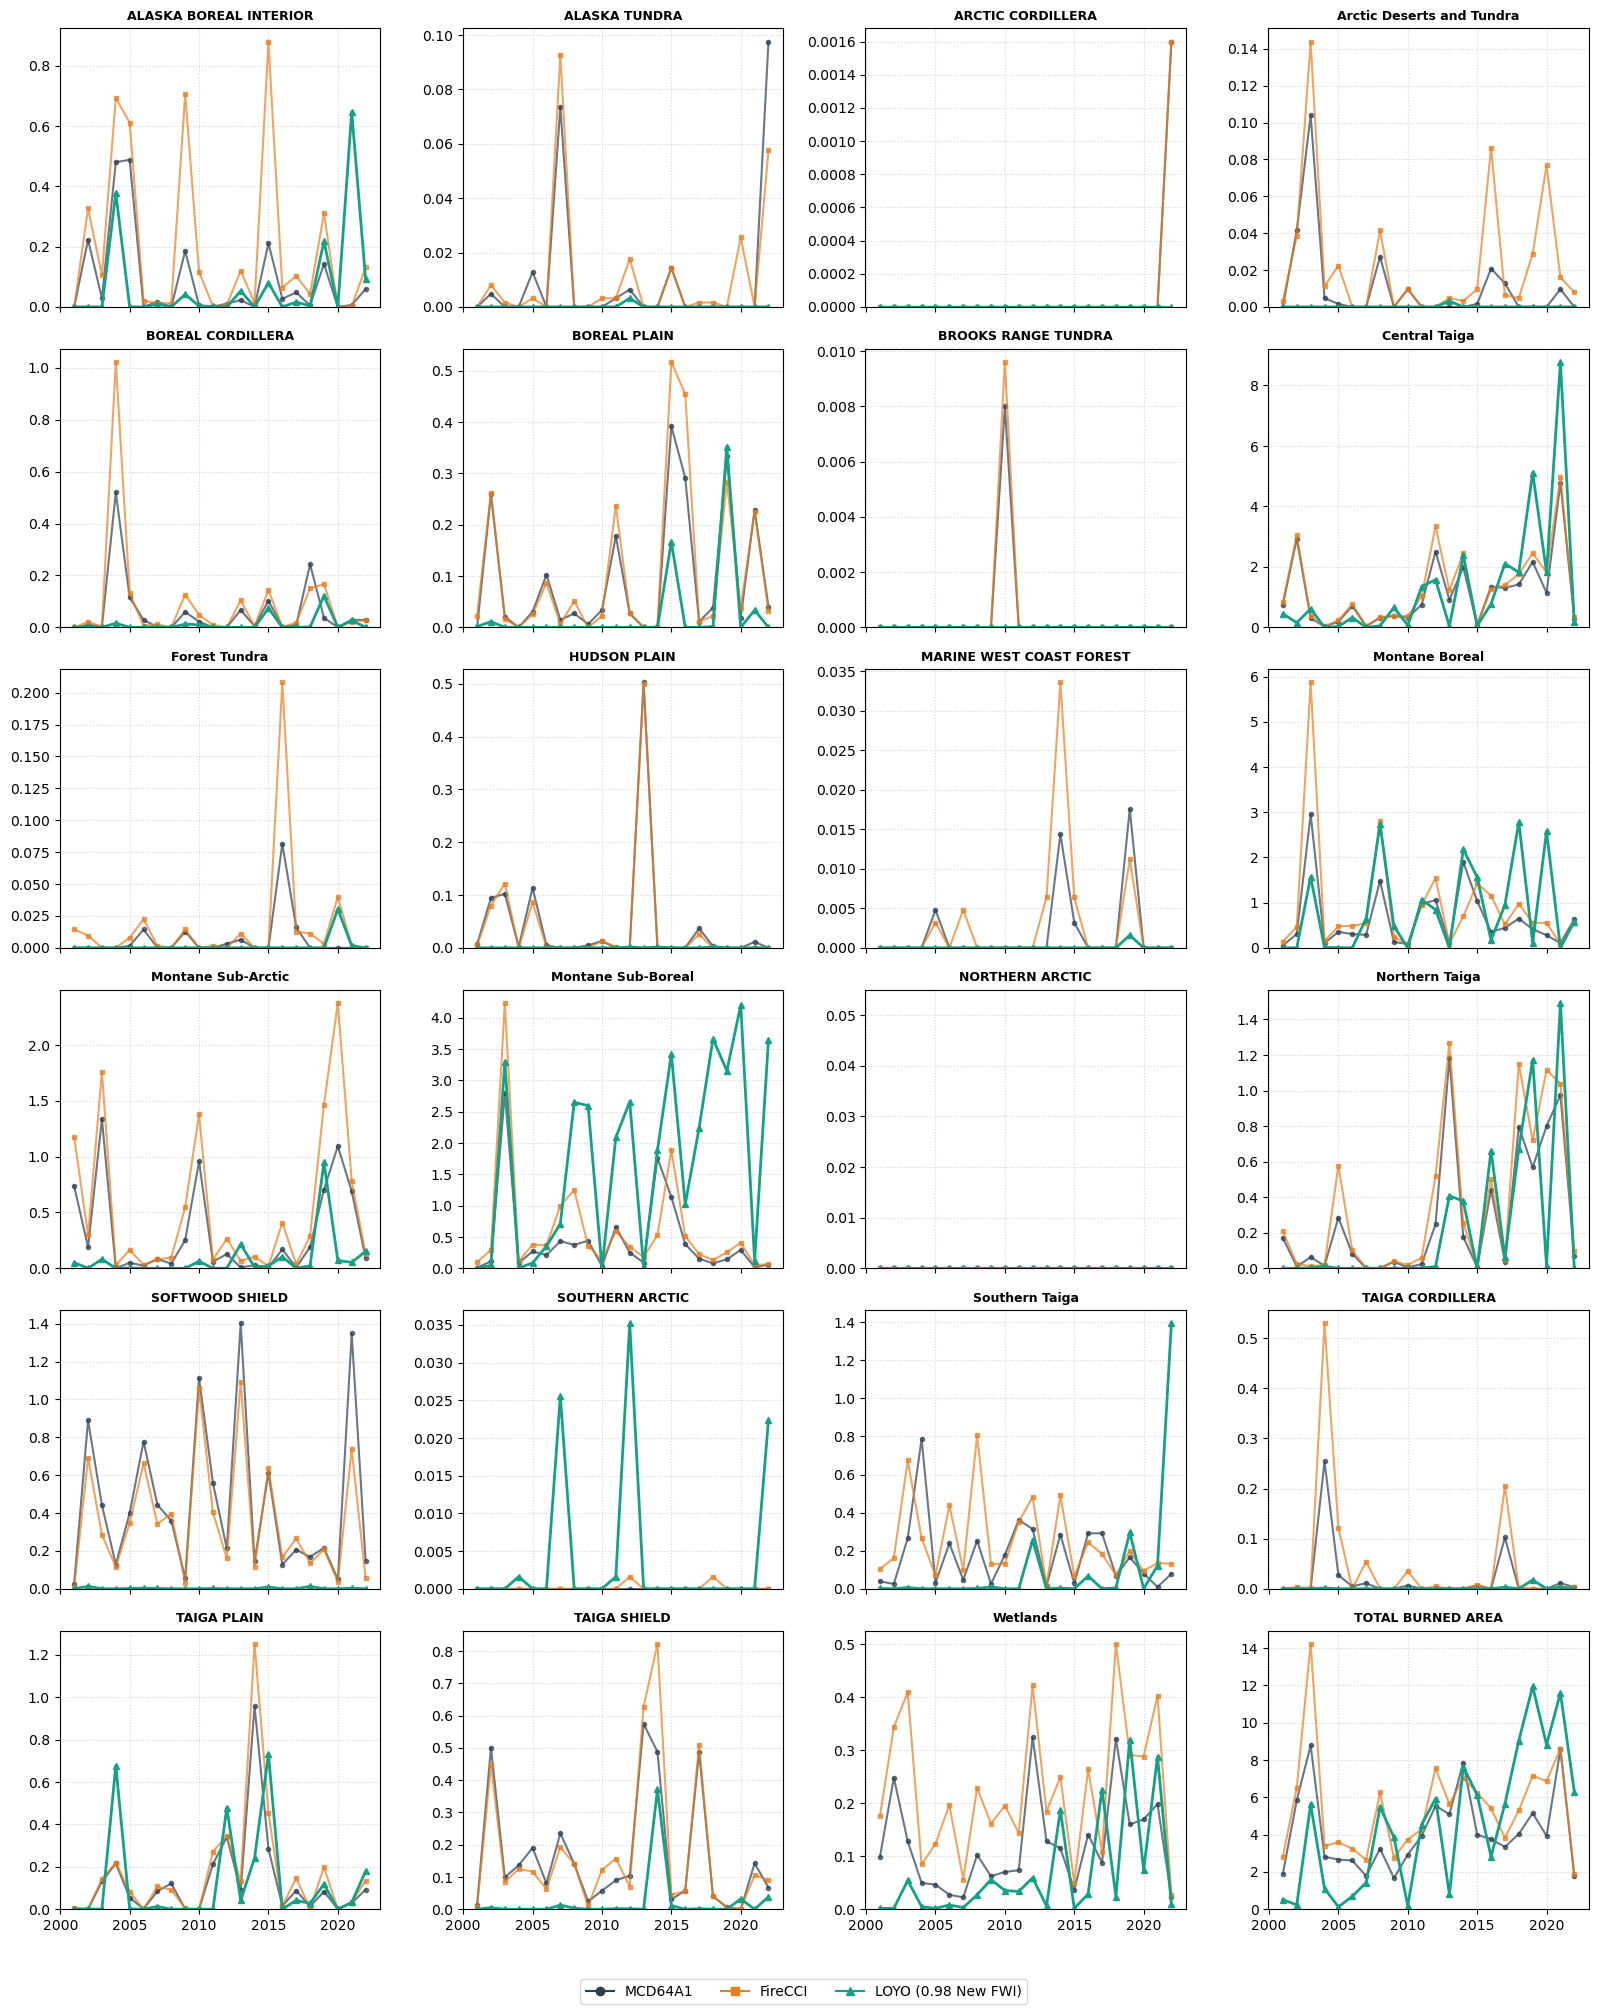

In [14]:
import os
import re
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from tqdm import tqdm

# ============================
# CONFIG
# ============================
# INPUT: Point to your pre-generated annual binary masks
ANNUAL_MASK_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/annual_masks_098")

# REFERENCE: Native MCD/FireCCI stats
REF_CSV = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/burned_area_summaries/burned_area_by_ecoregion_predictions.csv")

# ECOREGIONS
ECOS_PATH = "/explore/nobackup/people/spotter5/helene/raw/merge_eco_v2.shp"
ECO_ID_COL = "ecoregion"

# OUTPUT
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/burned_area_summaries_loyo_new_fwi")
OUT_DIR.mkdir(parents=True, exist_ok=True)
BA_CSV_OUT = OUT_DIR / "ba_ecoregion_loyo_098_new_fwi.csv"

# PLOT CONFIG
EXCLUDE_ECOS = {"WATER", "MIXED WOOD SHIELD", "TEMPERATE PRAIRIES", "WESTERN CORDILLERA"}
MCD_COL      = "ba_mcd_native_Mha"
FIRECCI_COL  = "ba_firecci_native_Mha"
PRED_COL     = "ba_pred_loyo_098_new_fwi_Mha" # Matching our output column

# ============================
# HELPERS
# ============================

def get_area_grid(shape, transform, crs):
    """Calculate pixel area in Mha."""
    height, width = shape
    res_x, res_y = abs(transform.a), abs(transform.e)
    if crs.is_geographic:
        rows = np.arange(height) + 0.5
        _, lats = rio.transform.xy(transform, rows, np.zeros_like(rows), offset='center')
        lat_rads = np.radians(lats)
        pixel_width_m = res_x * 111320 * np.cos(lat_rads)
        pixel_height_m = res_y * 111320
        row_areas_m2 = pixel_width_m * pixel_height_m
        area_grid = row_areas_m2[:, np.newaxis] * np.ones((1, width))
    else:
        area_grid = np.full(shape, res_x * res_y)
    return area_grid / 1e10 # m2 to Mha

# ============================
# MAIN
# ============================

def main():
    # 1. Gather Annual Mask Files
    mask_files = sorted(ANNUAL_MASK_DIR.glob("annual_mask_*_thresh098.tif"))
    if not mask_files:
        print(f"❌ No annual masks found in {ANNUAL_MASK_DIR}")
        return

    # 2. Load Ecoregions
    print(f"Loading ecoregions...")
    ecos = gpd.read_file(ECOS_PATH)
    results = []

    # 3. Process each Annual Mask
    for fpath in tqdm(mask_files, desc="Processing Annual Masks"):
        year_match = re.search(r"annual_mask_(\d{4})_", fpath.name)
        if not year_match: continue
        year = int(year_match.group(1))

        with rio.open(fpath) as src:
            mask = src.read(1)
            transform = src.transform
            crs = src.crs
            
            # Area grid for this specific year's projection/shape
            area_map = get_area_grid(mask.shape, transform, crs)
            
            # Reproject ecoregions if necessary
            ecos_proj = ecos.to_crs(crs) if ecos.crs != crs else ecos

            for _, row in ecos_proj.iterrows():
                eco_id = row[ECO_ID_COL]
                if eco_id in EXCLUDE_ECOS or row.geometry is None: continue
                
                # Create mask for this ecoregion
                e_mask = geometry_mask([row.geometry], transform=transform, invert=True, 
                                       out_shape=mask.shape, all_touched=False)
                
                # Burned pixels inside this ecoregion
                burned_in_eco = (mask == 1) & e_mask
                ba_mha = area_map[burned_in_eco].sum() if burned_in_eco.any() else 0.0
                
                results.append({"ecoregion": eco_id, "year": year, PRED_COL: ba_mha})

    df_results = pd.DataFrame(results)
    df_results.to_csv(BA_CSV_OUT, index=False)

    # 4. Merge with Reference Data for Plotting
    print("Merging with reference data and plotting...")
    df_ref = pd.read_csv(REF_CSV)
    df_final = df_ref.merge(df_results, on=["ecoregion", "year"], how="left")
    
    # Define plot titles (Individual ecos + Total)
    ecos_list = sorted([e for e in df_final["ecoregion"].unique() if e not in EXCLUDE_ECOS])
    plot_titles = ecos_list + ["TOTAL BURNED AREA"]
    
    ncols = 4
    nrows = int(np.ceil(len(plot_titles) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
    axes = axes.flatten()
    
    colors = {MCD_COL: "#2c3e50", FIRECCI_COL: "#e67e22", PRED_COL: "#16a085"}

    for i, title in enumerate(plot_titles):
        ax = axes[i]
        if title == "TOTAL BURNED AREA":
            df_p = df_final[~df_final["ecoregion"].isin(EXCLUDE_ECOS)].groupby("year").sum(numeric_only=True).reset_index()
            ax.set_facecolor('#fdfefe')
        else:
            df_p = df_final[df_final["ecoregion"] == title].sort_values("year")

        if df_p.empty: continue

        ax.plot(df_p["year"], df_p[MCD_COL], color=colors[MCD_COL], marker="o", ms=3, label="MCD64A1", alpha=0.7)
        ax.plot(df_p["year"], df_p[FIRECCI_COL], color=colors[FIRECCI_COL], marker="s", ms=3, label="FireCCI", alpha=0.7)
        ax.plot(df_p["year"], df_p[PRED_COL], color=colors[PRED_COL], marker="^", ms=4, lw=2, label="LOYO Pred (0.98)")
        
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_ylim(bottom=0)
        ax.grid(True, ls=":", alpha=0.5)

    # Global Legend
    handles = [mlines.Line2D([], [], color=c, marker=m, label=l) 
               for c, m, l in zip(colors.values(), ["o", "s", "^"], ["MCD64A1", "FireCCI", "LOYO (0.98 New FWI)"])]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.02))
    
    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()

if __name__ == "__main__":
    main()

Save new monthly files to force 0.99 threshold we found to match historical data to be 0.5 instead as they want to sample probabilities. 

In [19]:
import os
import re
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio as rio
import xgboost as xgb
import sys

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------
IN_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction")
MODELS_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/models")

# New directory for rescaled probability TIFFs
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs")
MONTHLY_RESCALED_DIR = OUT_DIR / "monthly_probs_rescaled_05"
MONTHLY_RESCALED_DIR.mkdir(parents=True, exist_ok=True)

# Math: To map 0.99 -> 0.5, we use k = 99.0
# Formula: p_new = p / (p + k*(1-p))
SHIFT_FACTOR = 99.0 

FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code",
    "fire_weather_index", "initial_fire_spread_index",
]

# ----------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------
def sanitize_names(names):
    seen = {}
    out = []
    for n in names:
        n0 = re.sub(r"[^a-zA-Z0-9_]", "_", str(n).strip()).strip("_")
        if n0 in seen:
            seen[n0] += 1
            n0 = f"{n0}_{seen[n0]}"
        else:
            seen[n0] = 1
        out.append(n0)
    return out

# ----------------------------------------------------------------------
# INFERENCE & RESCALING LOOP
# ----------------------------------------------------------------------
all_tifs = sorted(IN_DIR.glob("cems_e5l_firecci_*_new_fwi_with_fraction.tif"))
model_cache = {}

total_files = len(all_tifs)
print(f"Starting Rescaled Inference (0.99 -> 0.5) on {total_files} files...")

for i, tif_path in enumerate(all_tifs, 1):
    match = re.search(r"firecci_(\d{4})_(\d+)_", tif_path.name)
    if not match: continue
    
    year, month = int(match.group(1)), int(match.group(2))
    output_file = MONTHLY_RESCALED_DIR / f"prob_rescaled_{year}_{month:02d}.tif"
    
    if output_file.exists(): continue

    # Load model once per year
    if year not in model_cache:
        model_path = MODELS_DIR / f"xgb_loyo_{year}.json"
        if not model_path.exists():
            print(f"[{i}/{total_files}] ⚠️ Missing Model for {year}")
            continue
        
        bst = xgb.Booster()
        try:
            bst.set_param({'device': 'cuda'}) 
        except:
            bst.set_param({'device': 'cpu'})
        bst.load_model(str(model_path))
        model_cache[year] = bst
        print(f"--- Loaded Model {year} ---")
    
    bst = model_cache[year]

    with rio.open(tif_path) as src:
        out_meta = src.meta.copy()
        out_meta.update(dtype='float32', count=1, nodata=np.nan, compress='lzw')

        data = src.read().astype(np.float32)
        raw_descriptions = src.descriptions if src.descriptions else [f"B{i}" for i in range(1, src.count+1)]
        band_names = sanitize_names(raw_descriptions)
        
        df_pixels = pd.DataFrame(data.reshape(src.count, -1).T, columns=band_names)
        
        if "b1" in df_pixels.columns:
            df_pixels["b1"] = df_pixels["b1"].round().astype("Int64").astype("category")

        valid_mask = df_pixels["build_up_index"].notna().values
        probs_rescaled = np.full(len(df_pixels), np.nan, dtype=np.float32)

        if valid_mask.any():
            dtest = xgb.DMatrix(df_pixels.loc[valid_mask, FEATURES], enable_categorical=True)
            p_raw = bst.predict(dtest)
            
            # --- APPLY NON-LINEAR RESCALING ---
            # p_new = p / (p + SHIFT_FACTOR * (1 - p))
            denom = p_raw + (SHIFT_FACTOR * (1.0 - p_raw))
            probs_rescaled[valid_mask] = np.divide(p_raw, denom, out=np.zeros_like(p_raw), where=denom!=0)

        # Reshape to spatial grid
        prob_raster = probs_rescaled.reshape(src.height, src.width)
        
        with rio.open(output_file, 'w', **out_meta) as dst:
            dst.write(prob_raster, 1)
        
        print(f"[{i}/{total_files}] Saved Rescaled: {year}-{month:02d}")
        
        del data, df_pixels, probs_rescaled, prob_raster, valid_mask
        gc.collect()

print("✅ All rescaled monthly probability TIFFs generated.")

Starting Rescaled Inference (0.99 -> 0.5) on 264 files...
--- Loaded Model 2001 ---
[1/264] Saved Rescaled: 2001-10
[2/264] Saved Rescaled: 2001-11
[3/264] Saved Rescaled: 2001-12
[4/264] Saved Rescaled: 2001-01
[5/264] Saved Rescaled: 2001-02
[6/264] Saved Rescaled: 2001-03
[7/264] Saved Rescaled: 2001-04
[8/264] Saved Rescaled: 2001-05
[9/264] Saved Rescaled: 2001-06
[10/264] Saved Rescaled: 2001-07
[11/264] Saved Rescaled: 2001-08
[12/264] Saved Rescaled: 2001-09
--- Loaded Model 2002 ---
[13/264] Saved Rescaled: 2002-10
[14/264] Saved Rescaled: 2002-11
[15/264] Saved Rescaled: 2002-12
[16/264] Saved Rescaled: 2002-01
[17/264] Saved Rescaled: 2002-02
[18/264] Saved Rescaled: 2002-03
[19/264] Saved Rescaled: 2002-04
[20/264] Saved Rescaled: 2002-05
[21/264] Saved Rescaled: 2002-06
[22/264] Saved Rescaled: 2002-07
[23/264] Saved Rescaled: 2002-08
[24/264] Saved Rescaled: 2002-09
--- Loaded Model 2003 ---
[25/264] Saved Rescaled: 2003-10
[26/264] Saved Rescaled: 2003-11
[27/264] Saved 

New annual files

In [20]:
import os
import re
import gc
from pathlib import Path
import numpy as np
import rasterio as rio
from collections import defaultdict

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------
# Input: The NEW rescaled monthly probability TIFFs
PROB_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/monthly_probs_rescaled_05")

# Output: Directory for the final annual binary masks
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/annual_masks_rescaled_05")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Because we rescaled 0.99 -> 0.5, our target threshold is now 0.5
THRESHOLD = 0.5 

# ----------------------------------------------------------------------
# AGGREGATION LOOP
# ----------------------------------------------------------------------
# 1. Group monthly rescaled files by year
prob_files = sorted(PROB_DIR.glob("prob_rescaled_*.tif"))
year_to_files = defaultdict(list)

for f in prob_files:
    match = re.search(r"prob_rescaled_(\d{4})_\d{2}\.tif", f.name)
    if match:
        year_to_files[int(match.group(1))].append(f)

print(f"Found rescaled probabilities for {len(year_to_files)} years.")
print(f"Applying Binary Threshold: {THRESHOLD}")
print("-" * 50)

# 2. Process each year
for year in sorted(year_to_files.keys()):
    files = year_to_files[year]
    output_file = OUT_DIR / f"annual_mask_{year}_rescaled_05.tif"
    
    if output_file.exists():
        print(f"[{year}] ⏭️ Already exists. Skipping.")
        continue
    
    print(f"[{year}] Aggregating {len(files)} months...")
    
    annual_mask = None
    out_meta = None

    for fpath in files:
        with rio.open(fpath) as src:
            # Initialize metadata and array using the first month of the year
            if out_meta is None:
                out_meta = src.meta.copy()
                out_meta.update(
                    dtype='uint8',
                    count=1,
                    nodata=0,  # 0 for unburned/no-data
                    compress='lzw'
                )
                annual_mask = np.zeros((src.height, src.width), dtype='uint8')

            # Read the rescaled monthly probability
            p_rescaled = src.read(1)
            
            # Apply 0.5 threshold
            # np.maximum acts as a Logical OR: if a pixel is 1 in any month, it stays 1 for the year
            binary_month = (p_rescaled >= THRESHOLD).astype('uint8')
            annual_mask = np.maximum(annual_mask, binary_month)

    # 3. Save the Annual Mask
    if annual_mask is not None:
        with rio.open(output_file, 'w', **out_meta) as dst:
            dst.write(annual_mask, 1)
        print(f"[{year}] ✅ Saved: {output_file.name}")
    
    # Clean up memory
    del annual_mask
    gc.collect()

print("-" * 50)
print("✅ Annual binary mask generation (Rescaled 0.5) complete.")

Found rescaled probabilities for 22 years.
Applying Binary Threshold: 0.5
--------------------------------------------------
[2001] Aggregating 12 months...
[2001] ✅ Saved: annual_mask_2001_rescaled_05.tif
[2002] Aggregating 12 months...
[2002] ✅ Saved: annual_mask_2002_rescaled_05.tif
[2003] Aggregating 12 months...
[2003] ✅ Saved: annual_mask_2003_rescaled_05.tif
[2004] Aggregating 12 months...
[2004] ✅ Saved: annual_mask_2004_rescaled_05.tif
[2005] Aggregating 12 months...
[2005] ✅ Saved: annual_mask_2005_rescaled_05.tif
[2006] Aggregating 12 months...
[2006] ✅ Saved: annual_mask_2006_rescaled_05.tif
[2007] Aggregating 12 months...
[2007] ✅ Saved: annual_mask_2007_rescaled_05.tif
[2008] Aggregating 12 months...
[2008] ✅ Saved: annual_mask_2008_rescaled_05.tif
[2009] Aggregating 12 months...
[2009] ✅ Saved: annual_mask_2009_rescaled_05.tif
[2010] Aggregating 12 months...
[2010] ✅ Saved: annual_mask_2010_rescaled_05.tif
[2011] Aggregating 12 months...
[2011] ✅ Saved: annual_mask_2011_

compare burned area

In [ ]:
import os
import re
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from tqdm import tqdm

# ============================
# CONFIG
# ============================
# UPDATED: Points to the rescaled annual masks (0.99 -> 0.5)
ANNUAL_MASK_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_loyo_regularized_new_fwi/inference_outputs/annual_masks_rescaled_05")

# REFERENCE: Native MCD/FireCCI stats
REF_CSV = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/burned_area_summaries/burned_area_by_ecoregion_predictions.csv")

# ECOREGIONS
ECOS_PATH = "/explore/nobackup/people/spotter5/helene/raw/merge_eco_v2.shp"
ECO_ID_COL = "ecoregion"

# OUTPUT
OUT_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/burned_area_summaries_loyo_new_fwi")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Updated filename to reflect the rescaled 0.99 -> 0.5 approach
BA_CSV_OUT = OUT_DIR / "ba_ecoregion_loyo_rescaled_05_new_fwi.csv"

# PLOT CONFIG
EXCLUDE_ECOS = {"WATER", "MIXED WOOD SHIELD", "TEMPERATE PRAIRIES", "WESTERN CORDILLERA"}
MCD_COL      = "ba_mcd_native_Mha"
FIRECCI_COL  = "ba_firecci_native_Mha"

# Updated column name for the rescaled prediction
PRED_COL     = "ba_pred_loyo_rescaled_05_new_fwi_Mha" 

# ============================
# HELPERS
# ============================

def get_area_grid(shape, transform, crs):
    """Calculate pixel area in Mha."""
    height, width = shape
    res_x, res_y = abs(transform.a), abs(transform.e)
    if crs.is_geographic:
        rows = np.arange(height) + 0.5
        _, lats = rio.transform.xy(transform, rows, np.zeros_like(rows), offset='center')
        lat_rads = np.radians(lats)
        pixel_width_m = res_x * 111320 * np.cos(lat_rads)
        pixel_height_m = res_y * 111320
        row_areas_m2 = pixel_width_m * pixel_height_m
        area_grid = row_areas_m2[:, np.newaxis] * np.ones((1, width))
    else:
        area_grid = np.full(shape, res_x * res_y)
    return area_grid / 1e10 # m2 to Mha

# ============================
# MAIN
# ============================

def main():
    # 1. Gather Annual Mask Files (Rescaled versions)
    # Matching the filename pattern: annual_mask_YYYY_rescaled_05.tif
    mask_files = sorted(ANNUAL_MASK_DIR.glob("annual_mask_*_rescaled_05.tif"))
    if not mask_files:
        print(f"❌ No annual masks found in {ANNUAL_MASK_DIR}")
        return

    # 2. Load Ecoregions
    print(f"Loading ecoregions...")
    ecos = gpd.read_file(ECOS_PATH)
    results = []

    # 3. Process each Annual Mask
    for fpath in tqdm(mask_files, desc="Processing Annual Masks"):
        year_match = re.search(r"annual_mask_(\d{4})_", fpath.name)
        if not year_match: continue
        year = int(year_match.group(1))

        with rio.open(fpath) as src:
            mask = src.read(1)
            transform = src.transform
            crs = src.crs
            
            area_map = get_area_grid(mask.shape, transform, crs)
            ecos_proj = ecos.to_crs(crs) if ecos.crs != crs else ecos

            for _, row in ecos_proj.iterrows():
                eco_id = row[ECO_ID_COL]
                if eco_id in EXCLUDE_ECOS or row.geometry is None: continue
                
                e_mask = geometry_mask([row.geometry], transform=transform, invert=True, 
                                       out_shape=mask.shape, all_touched=False)
                
                # Pixels marked as 1 are the burned pixels
                burned_in_eco = (mask == 1) & e_mask
                ba_mha = area_map[burned_in_eco].sum() if burned_in_eco.any() else 0.0
                
                results.append({"ecoregion": eco_id, "year": year, PRED_COL: ba_mha})

    df_results = pd.DataFrame(results)
    df_results.to_csv(BA_CSV_OUT, index=False)

    # 4. Merge with Reference Data for Plotting
    print("Merging with reference data and plotting...")
    df_ref = pd.read_csv(REF_CSV)
    df_final = df_ref.merge(df_results, on=["ecoregion", "year"], how="left")
    
    ecos_list = sorted([e for e in df_final["ecoregion"].unique() if e not in EXCLUDE_ECOS])
    plot_titles = ecos_list + ["TOTAL BURNED AREA"]
    
    ncols = 4
    nrows = int(np.ceil(len(plot_titles) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
    axes = axes.flatten()
    
    colors = {MCD_COL: "#2c3e50", FIRECCI_COL: "#e67e22", PRED_COL: "#16a085"}

    for i, title in enumerate(plot_titles):
        ax = axes[i]
        if title == "TOTAL BURNED AREA":
            df_p = df_final[~df_final["ecoregion"].isin(EXCLUDE_ECOS)].groupby("year").sum(numeric_only=True).reset_index()
            ax.set_facecolor('#fdfefe')
        else:
            df_p = df_final[df_final["ecoregion"] == title].sort_values("year")

        if df_p.empty: continue

        ax.plot(df_p["year"], df_p[MCD_COL], color=colors[MCD_COL], marker="o", ms=3, label="MCD64A1", alpha=0.7)
        ax.plot(df_p["year"], df_p[FIRECCI_COL], color=colors[FIRECCI_COL], marker="s", ms=3, label="FireCCI", alpha=0.7)
        
        # Labeling it as the rescaled version where old 0.99 is now 0.5
        ax.plot(df_p["year"], df_p[PRED_COL], color=colors[PRED_COL], marker="^", ms=4, lw=2, label="LOYO Pred (Rescaled 0.5)")
        
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_ylim(bottom=0)
        ax.grid(True, ls=":", alpha=0.5)

    # Global Legend
    handles = [mlines.Line2D([], [], color=c, marker=m, label=l) 
               for c, m, l in zip(colors.values(), ["o", "s", "^"], ["MCD64A1", "FireCCI", "LOYO (Rescaled 0.5)"])]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.02))
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()

if __name__ == "__main__":
    main()

Loading ecoregions...


Processing Annual Masks:  23%|██▎       | 5/22 [00:32<01:50,  6.49s/it]